In [40]:
import cv2
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
import xgboost as xgb
import time
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

In [41]:
def load_images_from_folder(folder, label):
    images = []
    labels = []
    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder,filename))
        if img is not None:
            images.append(img)
            labels.append(label)
    return images, labels

In [42]:
def extract_lbp_features(image):
    # (Fungsi ini sama seperti sebelumnya)
    resized_image = cv2.resize(image, (128, 128))
    gray = cv2.cvtColor(resized_image, cv2.COLOR_BGR2GRAY)
    radius = 3
    n_points = 8 * radius
    lbp = local_binary_pattern(gray, n_points, radius, method='uniform')
    (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, n_points + 3), range=(0, n_points + 2))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-7)
    return hist

def extract_color_features(image):
    import numpy as np
    import cv2

    # Resize gambar untuk konsistensi dan konversi ke HSV
    resized_image = cv2.resize(image, (256, 256))
    hsv = cv2.cvtColor(resized_image, cv2.COLOR_BGR2HSV)
    
    # Pisahkan channel H, S, V
    h, s, v = cv2.split(hsv)
    
    # Hitung momen statistik untuk setiap channel
    h_mean, h_std = np.mean(h), np.std(h)
    s_mean, s_std = np.mean(s), np.std(s)
    v_mean, v_std = np.mean(v), np.std(v)
    
    h_skew, s_skew, v_skew = skew(h.flatten()), skew(s.flatten()), skew(v.flatten())
    h_kurt, s_kurt, v_kurt = kurtosis(h.flatten()), kurtosis(s.flatten()), kurtosis(v.flatten())

    # Gabungkan semua fitur menjadi satu vektor tunggal
    features = np.array([
        h_mean, h_std, h_skew, h_kurt,
        s_mean, s_std, s_skew, s_kurt,
        v_mean, v_std, v_skew, v_kurt
    ])
    
    return features

# --- FUNGSI HARALICK LAMA (NAMA DIUBAH) ---
def extract_haralick_features_simple(image):
    # (Nama fungsi ini diganti, isinya sama seperti 'extract_haralick_features' sebelumnya)
    resized_image = cv2.resize(image, (128, 128))
    gray = cv2.cvtColor(resized_image, cv2.COLOR_BGR2GRAY)
    glcm = graycomatrix(gray, distances=[5], angles=[0], levels=256, symmetric=True, normed=True)
    
    props = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']
    features = []
    for prop in props:
        features.append(graycoprops(glcm, prop)[0, 0])
    
    return np.array(features)


# --- FUNGSI HARALICK BARU YANG LEBIH CANGGIH ---
def extract_haralick_features_advanced(image):
    # Resize dan ubah ke grayscale
    resized_image = cv2.resize(image, (128, 128))
    gray = cv2.cvtColor(resized_image, cv2.COLOR_BGR2GRAY)

    # Tentukan beberapa jarak dan arah untuk analisis yang lebih lengkap
    distances = [1, 3, 5]
    angles = [0, np.pi/4, np.pi/2, 3*np.pi/4] # 0, 45, 90, 135 derajat

    # Hitung GLCM untuk semua kombinasi jarak dan arah
    glcm = graycomatrix(gray, distances=distances, angles=angles, levels=256, symmetric=True, normed=True)

    # Ekstrak properti. Hasilnya akan menjadi matriks (bukan satu nilai)
    props = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']
    features = []
    for prop in props:
        # Ambil rata-rata dan varians dari setiap properti di semua jarak/arah
        prop_matrix = graycoprops(glcm, prop)
        features.append(np.mean(prop_matrix))
        features.append(np.var(prop_matrix))
        
    # Hasilnya adalah vektor fitur dengan panjang 12 (6 properti * 2 statistik)
    return np.array(features)

# --- FITUR BARU: GABUNGAN (LBP + Color + Haralick) ---
def extract_combined_features(image):
    # Panggil setiap fungsi ekstraktor
    lbp = extract_lbp_features(image)
    color = extract_color_features(image)
    haralick = extract_haralick_features_simple(image)
    
    # Gabungkan semua fitur menjadi satu vektor
    combined = np.hstack([lbp, color, haralick])
    return combined

# --- FITUR BARU: GABOR FILTERS UNTUK TEKSTUR SPESIFIK ---
def extract_gabor_features_simple(image):
    # Resize dan ubah ke grayscale
    resized_image = cv2.resize(image, (128, 128))
    gray = cv2.cvtColor(resized_image, cv2.COLOR_BGR2GRAY)
    
    # Buat bank Gabor filter
    kernels = []
    for theta in range(4):  # 4 orientasi
        theta = theta / 4. * np.pi
        for sigma in (1, 3):  # 2 skala
            for frequency in (0.05, 0.25):  # 2 frekuensi
                kernel = cv2.getGaborKernel((9, 9), sigma, theta, 10.0, 0.5, 0, ktype=cv2.CV_32F)
                kernels.append(kernel)

    # Ekstrak fitur
    features = []
    for kernel in kernels:
        filtered_img = cv2.filter2D(gray, cv2.CV_8U, kernel)
        # Gunakan mean dan variance dari gambar hasil filter sebagai fitur
        features.extend([filtered_img.mean(), filtered_img.var()])
        
    return np.array(features)

# --- FUNGSI GABOR BARU YANG LEBIH CANGGIH ---
def extract_gabor_features_advanced(image):
    # Resize image
    resized_image = cv2.resize(image, (128, 128))
    # Konversi ke HSV dan ambil channel V (Value/Brightness)
    hsv = cv2.cvtColor(resized_image, cv2.COLOR_BGR2HSV)
    v_channel = hsv[:,:,2]
    
    # Buat bank Gabor filter yang lebih kaya (8 orientasi)
    kernels = []
    for theta in range(8): # Menggunakan 8 orientasi, bukan 4
        theta = theta / 8. * np.pi
        for sigma in (1, 3):
            for frequency in (0.05, 0.25):
                kernel = cv2.getGaborKernel((9, 9), sigma, theta, 10.0, 0.5, 0, ktype=cv2.CV_32F)
                kernels.append(kernel)
    
    # Ekstrak fitur dari V channel
    features = []
    for kernel in kernels:
        filtered_img = cv2.filter2D(v_channel, cv2.CV_8U, kernel)
        features.extend([filtered_img.mean(), filtered_img.var()])
        
    # Hasilnya adalah vektor fitur dengan panjang 64 (8*2*2*2)
    return np.array(features)


# --- FITUR BARU: ANALISIS KILAUAN (SPECULAR HIGHLIGHTS) ---
def extract_specular_features(image):
    # Resize image
    resized_image = cv2.resize(image, (128, 128))
    
    # Konversi ke HLS color space (Hue, Lightness, Saturation)
    # Channel Lightness (L) bagus untuk mendeteksi kilauan
    hls = cv2.cvtColor(resized_image, cv2.COLOR_BGR2HLS)
    l_channel = hls[:,:,1]
    
    # Cari piksel yang sangat terang (nilai lightness > 230)
    # Angka 230 bisa disesuaikan, tapi ini titik awal yang baik
    bright_pixels = np.sum(l_channel > 230)
    
    # Normalisasi dengan total jumlah piksel
    total_pixels = resized_image.shape[0] * resized_image.shape[1]
    specular_ratio = bright_pixels / total_pixels
    
    # Kita bisa juga menambahkan statistik dasar dari L-channel
    mean_lightness = l_channel.mean()
    var_lightness = l_channel.var()
    
    return np.array([specular_ratio, mean_lightness, var_lightness])

# Broth Detection
def extract_broth_detection_simple(image):
    gabor_feats = extract_gabor_features_simple(image)
    specular_feats = extract_specular_features(image)
    return np.hstack([gabor_feats, specular_feats])

def extract_broth_detection_advanced(image):
    gabor_feats = extract_gabor_features_advanced(image)
    specular_feats = extract_specular_features(image)
    return np.hstack([gabor_feats, specular_feats])


# Ultimate Combined
def extract_ultimate_combined_simple(image):
    haralick_feats = extract_haralick_features_simple(image)
    broth_feats = extract_broth_detection_simple(image)
    return np.hstack([haralick_feats, broth_feats])
    
def extract_ultimate_combined_advanced(image):
    haralick_feats = extract_haralick_features_advanced(image)
    broth_feats = extract_broth_detection_advanced(image)
    return np.hstack([haralick_feats, broth_feats])

# --- FITUR BARU: SIFT, ORB, AKAZE ---

def extract_keypoint_features(image, extractor, descriptor_size):
    """Fungsi pembantu untuk SIFT, ORB, AKAZE."""
    # Resize dan ubah ke grayscale
    resized_image = cv2.resize(image, (128, 128))
    gray = cv2.cvtColor(resized_image, cv2.COLOR_BGR2GRAY)
    
    # Deteksi keypoints dan hitung deskriptor
    keypoints, descriptors = extractor.detectAndCompute(gray, None)
    
    # Jika tidak ada keypoint yang terdeteksi, kembalikan vektor nol
    if descriptors is None:
        return np.zeros(descriptor_size)
    
    # Ambil rata-rata dari semua deskriptor sebagai fitur utama
    # Ini meringkas semua keypoint menjadi satu vektor fitur dengan panjang tetap
    feature_vector = np.mean(descriptors, axis=0)
    
    return feature_vector

def extract_sift_features(image):
    # Mungkin perlu: pip install opencv-contrib-python
    # Jika SIFT tidak ditemukan, coba ganti cv2.SIFT_create() dengan cv2.xfeatures2d.SIFT_create()
    try:
        sift = cv2.SIFT_create()
        return extract_keypoint_features(image, sift, 128)
    except cv2.error as e:
        print("Error saat membuat SIFT. Pastikan opencv-contrib-python terinstal.")
        print("Anda bisa melewati SIFT untuk sementara.")
        return np.zeros(128)

def extract_orb_features(image):
    # ORB biasanya memiliki 32-byte (256-bit) deskriptor
    orb = cv2.ORB_create()
    return extract_keypoint_features(image, orb, 32)

def extract_akaze_features(image):
    # AKAZE memiliki 61-byte (488-bit) deskriptor
    akaze = cv2.AKAZE_create()
    return extract_keypoint_features(image, akaze, 61)


In [43]:
# Load images
berkuah_images, berkuah_labels = load_images_from_folder('Makanan/Berkuah', 0)
tidak_berkuah_images, tidak_berkuah_labels = load_images_from_folder('Makanan/Tidak berkuah', 1)

# Combine images and labels
images = berkuah_images + tidak_berkuah_images
labels = berkuah_labels + tidak_berkuah_labels

In [ ]:
# ======================================================
# 0. Inisialisasi variabel global agar tidak NameError
# ======================================================
best_global_acc = -1
best_global_model = None
best_feature_extractor = None

# ======================================================
# 1. Definisikan metode ekstraksi fitur yang akan diuji
# ======================================================

feature_extractors = {
    "LBP": extract_lbp_features,
    "Color": extract_color_features,
    "Haralick_Simple": extract_haralick_features_simple,
    "Haralick_Advanced": extract_haralick_features_advanced,
    "Gabor_Simple": extract_gabor_features_simple,
    "Gabor_Advanced": extract_gabor_features_advanced,
    "Specular": extract_specular_features,

    # --- FITUR KEYPOINT ---
    "SIFT": extract_sift_features,
    "ORB": extract_orb_features,
    "AKAZE": extract_akaze_features,

    # --- Fitur gabungan ---
    "Broth_Detection_Simple": extract_broth_detection_simple,
    "Broth_Detection_Advanced": extract_broth_detection_advanced,
    "Ultimate_Combined_Simple": extract_ultimate_combined_simple,
    "Ultimate_Combined_Advanced": extract_ultimate_combined_advanced,
    "Combined_Old": extract_combined_features
}

# ======================================================
# 2. Definisikan model + parameter grid
# ======================================================

classifiers = {
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "RandomForest": RandomForestClassifier(random_state=42),

    # --- MODEL BARU ---
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier(
        random_state=42, 
        use_label_encoder=False, 
        eval_metric="logloss"
    )
}

param_grids = {
    "SVM": {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']},
    "KNN": {'n_neighbors': [3, 5, 7]},
    "RandomForest": {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20]},

    # --- PARAMETER MODEL BARU ---
    "GradientBoosting": {
        'n_estimators': [50, 100],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5]
    },
    "AdaBoost": {
        'n_estimators': [50, 100],
        'learning_rate': [0.5, 1.0]
    },
    "XGBoost": {
        'n_estimators': [50, 100],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5]
    }
}

# ======================================================
# 3. List hasil
# ======================================================
results = []

# ======================================================
# 4. Loop eksperimen utama
# ======================================================
for feature_name, extractor in feature_extractors.items():
    print("======================================================")
    print(f"MENGGUNAKAN FITUR: {feature_name}")
    print("======================================================")

    # Ekstrak fitur dari seluruh gambar
    features = []
    for img in images:
        f = extractor(img)
        f = np.array(f).flatten()
        features.append(f)

    # Cek konsistensi panjang fitur
    lengths = [len(f) for f in features]
    if len(set(lengths)) != 1:
        print(f"❌ SKIP extractor '{feature_name}' karena panjang fitur tidak konsisten:", set(lengths))
        continue

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

    # Loop semua model
    for model_name, model in classifiers.items():
        print(f"\n--- Menguji Model: {model_name} ---")

        grid = GridSearchCV(model, param_grids[model_name], cv=3, n_jobs=-1, scoring='accuracy')
        grid.fit(X_train, y_train)

        best_model = grid.best_estimator_

        y_pred = best_model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)

        # Laporkan hasil
        print(f"Parameter Terbaik: {grid.best_params_}")
        print(f"Akurasi: {accuracy*100:.2f}%")

        report = classification_report(
            y_test, y_pred,
            target_names=['Berkuah', 'Tidak Berkuah'],
            output_dict=True
        )

        print("Classification Report:")
        print(f"  - Presisi (Berkuah): {report['Berkuah']['precision']:.2f}")
        print(f"  - Recall (Berkuah):   {report['Berkuah']['recall']:.2f}")
        print(f"  - F1 (Berkuah):       {report['Berkuah']['f1-score']:.2f}")
        print(f"  - Presisi (Tidak Berkuah): {report['Tidak Berkuah']['precision']:.2f}")
        print(f"  - Recall (Tidak Berkuah):   {report['Tidak Berkuah']['recall']:.2f}")
        print(f"  - F1 (Tidak Berkuah):       {report['Tidak Berkuah']['f1-score']:.2f}")

        # Simpan model terbaik global
        if accuracy > best_global_acc:
            best_global_acc = accuracy
            best_global_model = best_model
            best_feature_extractor = feature_name

        # Simpan hasil tabel
        results.append({
            "Fitur": feature_name,
            "Model": model_name,
            "Akurasi": accuracy,
            "Parameter Terbaik": grid.best_params_
        })

# ======================================================
# 5. Ringkasan hasil
# ======================================================
print("\n\n======================================================")
print("RINGKASAN HASIL EKSPERIMEN")
print("======================================================")
results_df = pd.DataFrame(results)
print(results_df.to_string())


MENGGUNAKAN FITUR: LBP

--- Menguji Model: SVM ---


C:\Users\Vania Oriana Tanoto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Vania Oriana Tanoto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Vania Oriana Tanoto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\s

Parameter Terbaik: {'C': 0.1, 'kernel': 'linear'}
Akurasi: 33.33%
Classification Report:
  - Presisi (Berkuah): 0.33
  - Recall (Berkuah): 1.00
  - F1-Score (Berkuah): 0.50
  - Presisi (Tidak Berkuah): 0.00
  - Recall (Tidak Berkuah): 0.00
  - F1-Score (Tidak Berkuah): 0.00

--- Menguji Model: KNN ---
Parameter Terbaik: {'n_neighbors': 3}
Akurasi: 44.44%
Classification Report:
  - Presisi (Berkuah): 0.25
  - Recall (Berkuah): 0.33
  - F1-Score (Berkuah): 0.29
  - Presisi (Tidak Berkuah): 0.60
  - Recall (Tidak Berkuah): 0.50
  - F1-Score (Tidak Berkuah): 0.55

--- Menguji Model: RandomForest ---
Parameter Terbaik: {'max_depth': None, 'n_estimators': 50}
Akurasi: 55.56%
Classification Report:
  - Presisi (Berkuah): 0.33
  - Recall (Berkuah): 0.33
  - F1-Score (Berkuah): 0.33
  - Presisi (Tidak Berkuah): 0.67
  - Recall (Tidak Berkuah): 0.67
  - F1-Score (Tidak Berkuah): 0.67

--- Menguji Model: GradientBoosting ---
Parameter Terbaik: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators'

C:\Users\Vania Oriana Tanoto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [23:54:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Parameter Terbaik: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Akurasi: 55.56%
Classification Report:
  - Presisi (Berkuah): 0.33
  - Recall (Berkuah): 0.33
  - F1-Score (Berkuah): 0.33
  - Presisi (Tidak Berkuah): 0.67
  - Recall (Tidak Berkuah): 0.67
  - F1-Score (Tidak Berkuah): 0.67
MENGGUNAKAN FITUR: Color

--- Menguji Model: SVM ---
Parameter Terbaik: {'C': 10, 'kernel': 'rbf'}
Akurasi: 55.56%
Classification Report:
  - Presisi (Berkuah): 0.40
  - Recall (Berkuah): 0.67
  - F1-Score (Berkuah): 0.50
  - Presisi (Tidak Berkuah): 0.75
  - Recall (Tidak Berkuah): 0.50
  - F1-Score (Tidak Berkuah): 0.60

--- Menguji Model: KNN ---
Parameter Terbaik: {'n_neighbors': 7}
Akurasi: 55.56%
Classification Report:
  - Presisi (Berkuah): 0.40
  - Recall (Berkuah): 0.67
  - F1-Score (Berkuah): 0.50
  - Presisi (Tidak Berkuah): 0.75
  - Recall (Tidak Berkuah): 0.50
  - F1-Score (Tidak Berkuah): 0.60

--- Menguji Model: RandomForest ---
Parameter Terbaik: {'max_depth': None, 'n_e

...


--- Menguji Model: SVM ---
Parameter Terbaik: {'C': 0.1, 'kernel': 'linear'}
Akurasi: 44.44%
Classification Report:
  - Presisi (Berkuah): 0.38
  - Recall (Berkuah): 1.00
  - F1-Score (Berkuah): 0.55
  - Presisi (Tidak Berkuah): 1.00
  - Recall (Tidak Berkuah): 0.17
  - F1-Score (Tidak Berkuah): 0.29

--- Menguji Model: KNN ---
Parameter Terbaik: {'n_neighbors': 3}
Akurasi: 55.56%
Classification Report:
  - Presisi (Berkuah): 0.33
  - Recall (Berkuah): 0.33
  - F1-Score (Berkuah): 0.33
  - Presisi (Tidak Berkuah): 0.67
  - Recall (Tidak Berkuah): 0.67
  - F1-Score (Tidak Berkuah): 0.67

--- Menguji Model: RandomForest ---
Parameter Terbaik: {'max_depth': None, 'n_estimators': 100}
Akurasi: 66.67%
Classification Report:
  - Presisi (Berkuah): 0.50
  - Recall (Berkuah): 0.33
  - F1-Score (Berkuah): 0.40
  - Presisi (Tidak Berkuah): 0.71
  - Recall (Tidak Berkuah): 0.83
  - F1-Score (Tidak Berkuah): 0.77

--- Menguji Model: GradientBoosting ---
Parameter Terbaik: {'learning_rate': 0.05, 

C:\Users\Vania Oriana Tanoto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [23:54:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Menguji Model: SVM ---
Parameter Terbaik: {'C': 1, 'kernel': 'rbf'}
Akurasi: 33.33%
Classification Report:
  - Presisi (Berkuah): 0.20
  - Recall (Berkuah): 0.33
  - F1-Score (Berkuah): 0.25
  - Presisi (Tidak Berkuah): 0.50
  - Recall (Tidak Berkuah): 0.33
  - F1-Score (Tidak Berkuah): 0.40

--- Menguji Model: KNN ---
Parameter Terbaik: {'n_neighbors': 3}
Akurasi: 33.33%
Classification Report:
  - Presisi (Berkuah): 0.29
  - Recall (Berkuah): 0.67
  - F1-Score (Berkuah): 0.40
  - Presisi (Tidak Berkuah): 0.50
  - Recall (Tidak Berkuah): 0.17
  - F1-Score (Tidak Berkuah): 0.25

--- Menguji Model: RandomForest ---
Parameter Terbaik: {'max_depth': None, 'n_estimators': 100}
Akurasi: 55.56%
Classification Report:
  - Presisi (Berkuah): 0.33
  - Recall (Berkuah): 0.33
  - F1-Score (Berkuah): 0.33
  - Presisi (Tidak Berkuah): 0.67
  - Recall (Tidak Berkuah): 0.67
  - F1-Score (Tidak Berkuah): 0.67

--- Menguji Model: GradientBoosting ---
Parameter Terbaik: {'learning_rate': 0.1, 'max_d

C:\Users\Vania Oriana Tanoto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [23:55:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Menguji Model: SVM ---
Parameter Terbaik: {'C': 1, 'kernel': 'rbf'}
Akurasi: 66.67%
Classification Report:
  - Presisi (Berkuah): 0.50
  - Recall (Berkuah): 1.00
  - F1-Score (Berkuah): 0.67
  - Presisi (Tidak Berkuah): 1.00
  - Recall (Tidak Berkuah): 0.50
  - F1-Score (Tidak Berkuah): 0.67

--- Menguji Model: KNN ---
Parameter Terbaik: {'n_neighbors': 3}
Akurasi: 77.78%
Classification Report:
  - Presisi (Berkuah): 0.60
  - Recall (Berkuah): 1.00
  - F1-Score (Berkuah): 0.75
  - Presisi (Tidak Berkuah): 1.00
  - Recall (Tidak Berkuah): 0.67
  - F1-Score (Tidak Berkuah): 0.80

--- Menguji Model: RandomForest ---


Memulai evaluasi dengan uji coba berulang...
Fitur yang dibutuhkan sudah diekstrak: [np.str_('Gabor_Simple'), np.str_('Haralick_Advanced'), np.str_('Haralick_Simple')]
--> Mengevaluasi pasangan: Haralick_Advanced + GradientBoosting
--> Mengevaluasi pasangan: Haralick_Advanced + AdaBoost
--> Mengevaluasi pasangan: Haralick_Simple + RandomForest
--> Mengevaluasi pasangan: Haralick_Simple + XGBoost


C:\Users\Vania Oriana Tanoto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [23:53:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Vania Oriana Tanoto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [23:53:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Vania Oriana Tanoto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [23:53:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:

--> Mengevaluasi pasangan: Gabor_Simple + KNN

Evaluasi selesai dalam 12.21 detik.


C:\Users\Vania Oriana Tanoto\AppData\Local\Temp\ipykernel_12460\1227440383.py:93: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', 10)


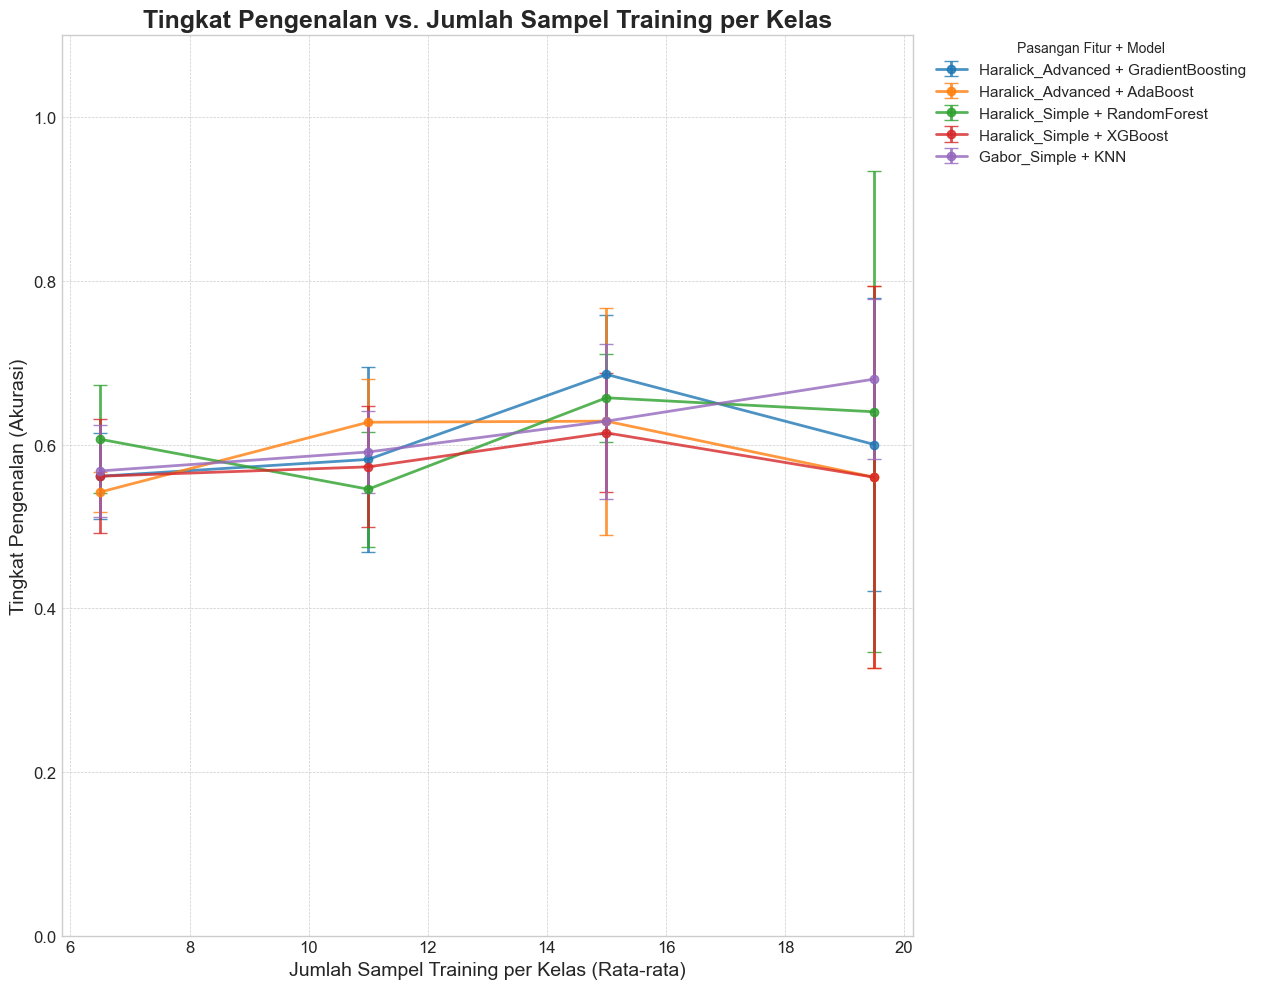

In [ ]:
# Mengatur backend matplotlib agar bisa menampilkan plot di notebook
%matplotlib inline

# --- Asumsi variabel-variabel ini sudah ada dari eksekusi sel sebelumnya: ---
# 
# feature_extractors: Dictionary yang berisi semua fungsi ekstraksi fitur.
# classifiers: Dictionary yang berisi semua model classifier.
# images: List yang berisi semua gambar.
# labels: List yang berisi semua label.
#
# --------------------------------------------------------------------------------

# 1. Definisikan 10 pasangan Fitur-Model terbaik dan parameternya
top_10_pairs = [
    {'fitur': 'Haralick_Advanced', 'model': 'GradientBoosting', 'params': {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}},
    {'fitur': 'Haralick_Advanced', 'model': 'AdaBoost', 'params': {'learning_rate': 1.0, 'n_estimators': 100}},
    {'fitur': 'Haralick_Simple', 'model': 'RandomForest', 'params': {'max_depth': None, 'n_estimators': 200}},
    {'fitur': 'Haralick_Simple', 'model': 'XGBoost', 'params': {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50}},
    {'fitur': 'Gabor_Simple', 'model': 'KNN', 'params': {'n_neighbors': 5}},
    # {'fitur': 'ORB', 'model': 'SVM', 'params': {'C': 0.1, 'kernel': 'linear'}},
    # {'fitur': 'AKAZE', 'model': 'RandomForest', 'params': {'max_depth': None, 'n_estimators': 200}},
    # {'fitur': 'Ultimate_Combined_Simple', 'model': 'GradientBoosting', 'params': {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}},
    # {'fitur': 'SIFT', 'model': 'RandomForest', 'params': {'max_depth': None, 'n_estimators': 100}},
    # {'fitur': 'SIFT', 'model': 'AdaBoost', 'params': {'learning_rate': 0.5, 'n_estimators': 100}}
]

# 2. Tentukan parameter eksperimen
training_sizes_percentage = [0.3, 0.5, 0.7, 0.9] # Persentase data training
n_trials = 5 # Jumlah pengulangan per data point untuk menghitung std dev (bisa dinaikkan)

# Dictionary untuk menyimpan hasil (mean dan std dev)
results_summary = {}

# 3. Lakukan eksperimen
print("Memulai evaluasi dengan uji coba berulang...")
start_time = time.time()

# Pre-ekstrak semua fitur yang dibutuhkan untuk efisiensi
unique_features = np.unique([p['fitur'] for p in top_10_pairs])
extracted_features_cache = {
    fname: [np.array(feature_extractors[fname](img)).flatten() for img in images]
    for fname in unique_features
}
print(f"Fitur yang dibutuhkan sudah diekstrak: {list(unique_features)}")

for pair in top_10_pairs:
    pair_name = f"{pair['fitur']} + {pair['model']}"
    print(f"--> Mengevaluasi pasangan: {pair_name}")
    
    results_summary[pair_name] = {'mean': [], 'std': [], 'train_samples': []}
    
    current_features = extracted_features_cache[pair['fitur']]
    
    for train_percent in training_sizes_percentage:
        accuracies_for_current_size = []
        
        # Hitung jumlah sampel training rata-rata per kelas untuk sumbu X
        num_train_samples = int(len(images) * train_percent)
        num_train_per_class = num_train_samples / len(np.unique(labels))
        results_summary[pair_name]['train_samples'].append(num_train_per_class)

        for i in range(n_trials):
            # Split data dengan random_state berbeda setiap trial untuk variasi
            X_train, X_test, y_train, y_test = train_test_split(
                current_features, labels, train_size=train_percent, random_state=i, stratify=labels
            )
            
            # Inisialisasi & training
            model = classifiers[pair['model']]
            model.set_params(**pair['params'])
            model.fit(X_train, y_train)
            
            # Evaluasi
            y_pred = model.predict(X_test)
            accuracy = accuracy_score(y_test, y_pred)
            accuracies_for_current_size.append(accuracy)
            
        # Hitung mean dan std dev dari semua trial
        mean_accuracy = np.mean(accuracies_for_current_size)
        std_accuracy = np.std(accuracies_for_current_size)
        
        results_summary[pair_name]['mean'].append(mean_accuracy)
        results_summary[pair_name]['std'].append(std_accuracy)

end_time = time.time()
print(f"\nEvaluasi selesai dalam {end_time - start_time:.2f} detik.")

# 4. Buat Line Chart dengan Error Bars
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(16, 10))

# Dapatkan 10 warna berbeda dari colormap 'tab10'
colors = plt.cm.get_cmap('tab10', 10)

for i, (pair_name, data) in enumerate(results_summary.items()):
    ax.errorbar(
        x=data['train_samples'], 
        y=data['mean'], 
        yerr=data['std'], 
        label=pair_name,
        fmt='-o', # Format: garis dengan marker bulat
        capsize=5, # Ukuran topi di ujung error bar
        color=colors(i),
        linewidth=2,
        markersize=6,
        alpha=0.8
    )

ax.set_title('Tingkat Pengenalan vs. Jumlah Sampel Training per Kelas', fontsize=18, fontweight='bold')
ax.set_xlabel('Jumlah Sampel Training per Kelas (Rata-rata)', fontsize=14)
ax.set_ylabel('Tingkat Pengenalan (Akurasi)', fontsize=14)
ax.tick_params(axis='both', labelsize=12)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.set_ylim(0, 1.1)

# Pindahkan legenda ke luar plot agar tidak menutupi data
ax.legend(title='Pasangan Fitur + Model', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., fontsize=11)

# Atur layout agar legenda tidak terpotong
plt.tight_layout(rect=[0, 0, 0.8, 1]) 
plt.show()

In [ ]:
import pickle
import json

# Pastikan variabel berikut sudah ada:
# model → model terlatih (SVM/KNN/RandomForest/XGBoost/dll)
# scaler → StandardScaler / MinMaxScaler / RobustScaler (opsional)
# encoder → LabelEncoder / OneHotEncoder / OrdinalEncoder (opsional)
# selected_features → list nama fitur yang digunakan model
# feature_extractor_name → nama metode ekstraksi fitur (LBP, Haralick, Gabor, dll)

# Gunakan model terbaik yang ditemukan
model = best_global_model
feature_extractor_name = best_feature_extractor
scaler = None
encoder = None
selected_features = None

export_data = {
    "model": model,
    "scaler": scaler,
    "encoder": encoder,
    "selected_features": selected_features,
    "feature_extractor": feature_extractor_name
}

with open("model_makanan_full.pkl", "wb") as f:
    pickle.dump(export_data, f)

print("✔ File 'model_makanan_full.pkl' berhasil dibuat!")
print(f"Model terbaik menggunakan fitur: {feature_extractor_name}")


# Simpan ke file PKL
with open("model_makanan_full.pkl", "wb") as f:
    pickle.dump(export_data, f)

print("✔ File 'model_makanan_full.pkl' berhasil dibuat!")


NameError: name 'best_global_model' is not defined

In [ ]:
saved.get("feature_extractor")



NameError: name 'saved' is not defined

In [ ]:
sample = images[0]   # ambil 1 gambar
f = extract_haralick_features_simple(sample)
print(f.shape)
print(f)


(6,)
[2.59581580e+03 3.59702744e+01 4.42008319e-02 9.61238386e-03
 4.72879181e-01 9.23979234e-05]
